# Diagnostics: SMD, Love Plot, ATE Tracker, Overlap, Drift

This notebook demonstrates all five OnlineCML diagnostic tools:

| Tool | Purpose |
|---|---|
| `OnlineSMD` | Covariate balance (raw and IPW-weighted SMD) |
| `LiveLovePlot` | Visual balance check (dot plot) |
| `ATETracker` | ATE convergence history with CI band |
| `OverlapChecker` | Propensity score overlap diagnostics |
| `ConceptDriftMonitor` | ADWIN drift detection on pseudo-outcomes |

In [1]:
import matplotlib
import matplotlib.pyplot as plt

from onlinecml.datasets import LinearCausalStream, UnbalancedCausalStream
from onlinecml.diagnostics import OnlineSMD, ATETracker, OverlapChecker, ConceptDriftMonitor
from onlinecml.diagnostics.live_love_plot import LiveLovePlot
from onlinecml.reweighting import OnlineIPW

## 1. Covariate balance with OnlineSMD

In [2]:
ipw = OnlineIPW()
smd = OnlineSMD(covariates=["x0", "x1", "x2", "x3", "x4"])

for x, w, y, _ in LinearCausalStream(n=1000, confounding_strength=1.0, seed=0):
    ps = ipw.ps_model.predict_one(x)
    weight = 1.0 / ps if w == 1 else 1.0 / (1.0 - ps)
    smd.update(x, treatment=w, weight=weight)
    ipw.learn_one(x, w, y)

print(f"Balance adequate: {smd.is_balanced()}\n")
print(f"{'Covariate':>10} | {'Raw SMD':>9} | {'Weighted SMD':>13}")
print("-" * 38)
for cov, (raw, weighted) in smd.report().items():
    print(f"{cov:>10} | {raw:>+9.3f} | {weighted:>+13.3f}")

Balance adequate: False

 Covariate |   Raw SMD |  Weighted SMD
--------------------------------------
        x0 |    +0.093 |        +0.033
        x1 |    -0.097 |        -0.031
        x2 |    +0.258 |        +0.134
        x3 |    -0.020 |        -0.019
        x4 |    -0.155 |        -0.078


## 2. LiveLovePlot

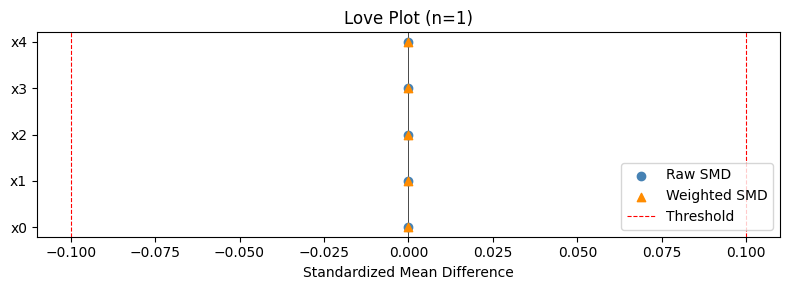

Saved to /tmp/love_plot.png


In [3]:
love = LiveLovePlot(covariates=["x0", "x1", "x2", "x3", "x4"], update_every=1)

ipw2 = OnlineIPW()
for x, w, y, _ in LinearCausalStream(n=500, confounding_strength=1.0, seed=1):
    ps = ipw2.ps_model.predict_one(x)
    weight = 1.0 / ps if w == 1 else 1.0 / (1.0 - ps)
    love.update(x, treatment=w, weight=weight)
    ipw2.learn_one(x, w, y)

ax = love.render()
if ax is not None:
    ax.figure.savefig("/tmp/love_plot.png", dpi=100, bbox_inches="tight")
    print("Saved to /tmp/love_plot.png")

## 3. ATETracker convergence

Final ATE: 2.087
CI width : 0.399


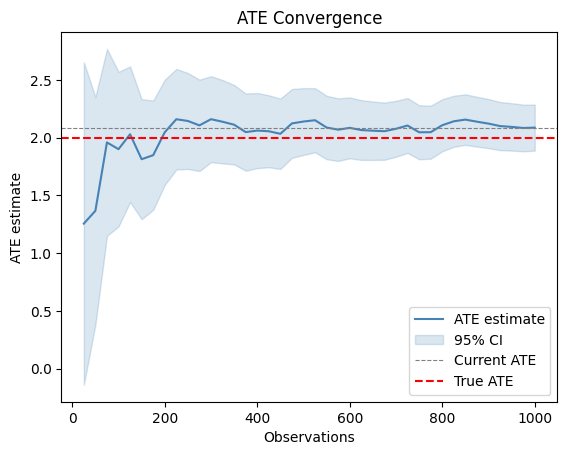

In [4]:
tracker = ATETracker(log_every=25)
ipw3 = OnlineIPW()

for x, w, y, _ in LinearCausalStream(n=1000, true_ate=2.0, seed=0):
    ipw3.learn_one(x, w, y)
    ps = max(0.01, min(0.99, ipw3.ps_model.predict_one(x)))
    psi = (w * y / ps) - ((1 - w) * y / (1 - ps))
    tracker.update(psi)

ax = tracker.plot()
ax.axhline(2.0, color="red", linestyle="--", label="True ATE")
ax.legend()
ax.figure.savefig("/tmp/ate_tracker.png", dpi=100)
print(f"Final ATE: {tracker.ate:.3f}")
print(f"CI width : {tracker.convergence_width():.3f}")

## 4. OverlapChecker on unbalanced data

In [5]:
checker = OverlapChecker(ps_min=0.05, ps_max=0.95)
ipw4 = OnlineIPW()

for x, w, y, _ in UnbalancedCausalStream(n=500, treatment_rate=0.1, seed=0):
    ps = ipw4.ps_model.predict_one(x)
    checker.update(ps, treatment=w)
    ipw4.learn_one(x, w, y)

r = checker.report()
print(f"Total obs    : {r['n_total']}")
print(f"Flagged      : {r['n_flagged']} ({r['flag_rate']:.1%})")
print(f"Common support rate: {r['common_support_rate']:.1%}")
print(f"Mean PS (treated)  : {r['mean_ps_treated']:.3f}")
print(f"Mean PS (control)  : {r['mean_ps_control']:.3f}")
print(f"Overlap adequate   : {checker.is_overlap_adequate()}")

Total obs    : 500
Flagged      : 0 (0.0%)
Common support rate: 100.0%
Mean PS (treated)  : 0.365
Mean PS (control)  : 0.342
Overlap adequate   : True


## 5. ConceptDriftMonitor

In [6]:
from onlinecml.datasets import DriftingCausalStream

monitor = ConceptDriftMonitor(delta=0.002)
ipw5 = OnlineIPW()

drift_points = []

for i, (x, w, y, tau) in enumerate(
    DriftingCausalStream(n=2000, true_ate=2.0, shifted_ate=-1.0, changepoint=1000, seed=0)
):
    ipw5.learn_one(x, w, y)
    ps = max(0.01, min(0.99, ipw5.ps_model.predict_one(x)))
    psi = (w * y / ps) - ((1 - w) * y / (1 - ps))
    monitor.update(psi)
    if monitor.drift_detected:
        drift_points.append(i)

print(f"True changepoint    : step 1000")
print(f"Detected drifts     : {monitor.n_drifts}")
print(f"Drift detection steps: {drift_points[:5]}")

True changepoint    : step 1000


Detected drifts     : 1
Drift detection steps: [1055]
